In [194]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore

### Importing dataset

In [195]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

In [196]:
data_part_1 = pd.read_csv("/home/mendrika/mendrika-phd/data/other-location/AirMountain/full-data-train-5nearest-AirMountain-different-lead-times-part1.csv", index_col=False)
data_part_2 = pd.read_csv("/home/mendrika/mendrika-phd/data/other-location/AirMountain/full-data-train-5nearest-AirMountain-different-lead-times-part2.csv", index_col=False)
data_part_3 = pd.read_csv("/home/mendrika/mendrika-phd/data/other-location/AirMountain/full-data-train-5nearest-AirMountain-different-lead-times-part3.csv", index_col=False)
data_part_4 = pd.read_csv("/home/mendrika/mendrika-phd/data/other-location/AirMountain/full-data-train-5nearest-AirMountain-different-lead-times-part4.csv", index_col=False)
test_data = pd.read_csv("/home/mendrika/mendrika-phd/data/other-location/AirMountain/full-data-test-5nearest-AirMountain-different-lead-times.csv", index_col=False)

In [197]:
data = pd.concat([data_part_1, data_part_2, data_part_3, data_part_4])

In [198]:
variable = "lat"
for i in range(5):
    print(np.min(test_data[f"{variable}{i+1}"]), np.max(test_data[f"{variable}{i+1}"]))

13.03 19.5
13.03 19.5
13.03 19.5
13.03 19.5
13.03 3834.0


In [199]:
def select(df):
    selection_index_lat = df["lat5"] < 30
    selection_index_lon = df["lon5"] < 30
    selection_index = selection_index_lat * selection_index_lon
    return selection_index

index_train = select(data)
index_test = select(test_data)

data = data[index_train]
test_data = test_data[index_test]

#### combining dataset and doing some exploratory analysis

In [200]:
data = data.dropna()
test_data = test_data.dropna()

In [201]:
test_data

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_AirMountain_t1,Cb_AirMountain_t3,Cb_AirMountain_t6
0,2020,6,4,0,45,13.25,8.08,13.66,8.35,16.25,...,0.0,0.0,157.28,171.35,500.00,500.0,500.0,0.0,0.0,0.0
1,2020,6,4,1,0,13.25,7.95,13.07,7.23,13.66,...,0.0,0.0,157.28,171.11,178.02,500.0,500.0,0.0,0.0,0.0
2,2020,6,4,2,45,13.16,7.68,13.84,7.32,16.25,...,0.0,0.0,150.96,174.03,500.00,500.0,500.0,0.0,0.0,0.0
3,2020,6,4,3,0,13.16,7.63,13.75,7.18,16.25,...,0.0,0.0,154.57,174.07,500.00,500.0,500.0,0.0,0.0,0.0
4,2020,6,4,3,15,13.75,7.05,13.03,6.24,16.25,...,0.0,0.0,155.36,186.01,500.00,500.0,500.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9390,2022,9,30,2,15,15.50,6.15,14.91,6.51,16.25,...,0.0,0.0,109.84,121.46,500.00,500.0,500.0,0.0,0.0,0.0
9391,2022,9,30,4,45,13.75,6.06,15.54,6.06,16.25,...,0.0,0.0,110.44,165.08,500.00,500.0,500.0,0.0,0.0,0.0
9392,2022,9,30,13,15,17.61,8.40,14.38,7.14,16.25,...,0.0,0.0,24.21,133.18,500.00,500.0,500.0,1.0,0.0,0.0
9393,2022,9,30,13,30,17.65,8.44,14.38,7.05,16.25,...,0.0,0.0,24.08,133.75,500.00,500.0,500.0,1.0,0.0,0.0


#### Choosing field to include in the data

In [202]:
lead_time = 1

In [203]:
# Presence or absence of convection in Dakar at time t+1
target_index = f"Cb_AirMountain_t{lead_time}"

# Input at time t
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"
features = t0 + location + wavelet_power + storm_size + distance
field =  features + target_index
field = field.split(',')
data = data[field]
test_data = test_data[field]

In [204]:
data.describe()

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_AirMountain_t1
count,42991.000000,42991.000000,42991.000000,42991.000000,42991.000000,42991.000000,42991.000000,42991.000000,42991.000000,42991.000000,...,42991.000000,42991.000000,42991.000000,42991.000000,42991.000000,42991.000000,42991.000000,42991.000000,42991.000000,42991.000000
mean,2011.737875,7.628597,15.589356,14.429253,22.313159,14.961485,10.487391,14.856287,10.509510,15.303690,...,7877.912237,5399.618525,3743.783001,2649.399293,136.258459,174.593357,282.147980,350.692423,395.580875,0.068037
std,4.657567,0.914192,8.704730,6.615648,16.775125,1.537869,3.493419,1.534920,3.520405,1.393914,...,8075.105802,7549.432008,6622.552904,5746.649403,83.994326,90.361687,160.700247,161.671182,147.978824,0.251813
min,2004.000000,6.000000,1.000000,0.000000,0.000000,13.030000,6.020000,13.030000,6.020000,13.030000,...,75.000000,0.000000,0.000000,0.000000,1.000000,4.120000,14.320000,18.030000,22.360000,0.000000
25%,2008.000000,7.000000,8.000000,12.000000,0.000000,13.750000,7.540000,13.660000,7.500000,14.060000,...,2125.000000,0.000000,0.000000,0.000000,70.980000,110.660000,149.720000,180.545000,257.640000,0.000000
50%,2012.000000,8.000000,15.000000,16.000000,15.000000,14.560000,9.430000,14.420000,9.430000,15.500000,...,5350.000000,2300.000000,0.000000,0.000000,128.830000,162.780000,234.440000,500.000000,500.000000,0.000000
75%,2016.000000,8.000000,23.000000,19.000000,30.000000,15.900000,13.340000,15.720000,13.380000,16.250000,...,10800.000000,7850.000000,4950.000000,2425.000000,176.150000,232.440000,500.000000,500.000000,500.000000,0.000000
max,2019.000000,9.000000,31.000000,23.000000,45.000000,19.500000,17.960000,19.500000,17.960000,19.500000,...,80950.000000,79000.000000,66325.000000,72625.000000,386.850000,396.270000,500.000000,500.000000,500.000000,1.000000


### Exploratory data analysis

In [205]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [206]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [207]:
to_scale = wavelet_power + storm_size + distance

In [208]:
transform = True
if transform:
    data = log_transform(data, to_scale.split(',')[:-1])    
    data = sqrt_transform(data, t0.split(',')[:-1])
    test_data = log_transform(test_data, to_scale.split(',')[:-1])    
    test_data = sqrt_transform(test_data, t0.split(',')[:-1])

#### splitting the data  into training and testing before oversampling the training set

In [209]:
train, validation = train_test_split(data, test_size=0.2, random_state=12)

In [210]:
train

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_AirMountain_t1
806,44.810713,2.645751,4.242641,4.358899,0.000000,18.55,13.16,18.82,12.75,18.46,...,7.130899,6.829794,8.181720,7.296413,3.851636,5.082956,5.161065,5.299167,5.389163,0.0
2620,44.777226,2.449490,5.196152,3.872983,0.000000,14.78,13.70,14.15,14.10,13.16,...,9.017968,8.491875,7.226209,8.691146,5.463069,5.559219,5.610314,5.731819,5.853552,0.0
5785,44.833024,2.645751,4.690416,4.000000,3.872983,13.70,13.74,15.05,12.08,14.73,...,6.396930,9.506734,-18.420681,-18.420681,5.209486,5.237611,5.559912,6.214608,6.214608,0.0
1302,44.766059,2.828427,3.316625,3.872983,3.872983,14.56,13.16,18.15,8.26,13.57,...,7.423568,9.038959,9.478457,-18.420681,2.221375,3.168424,5.277502,5.413430,6.214608,1.0
10112,44.799554,3.000000,3.162278,4.690416,6.708204,13.25,11.94,14.42,11.45,14.33,...,9.661416,7.150701,-18.420681,-18.420681,5.206531,5.418808,5.573104,6.214608,6.214608,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,44.922155,2.449490,2.236068,4.358899,5.477226,14.20,6.78,13.07,6.37,13.75,...,9.474626,9.347926,-18.420681,-18.420681,4.955193,5.035198,5.214555,6.214608,6.214608,0.0
9230,44.933284,2.449490,5.000000,4.690416,0.000000,13.57,7.99,15.50,7.68,13.70,...,9.958212,9.474626,7.495542,7.438384,4.524719,5.044908,5.076111,5.124440,5.177787,0.0
9541,44.844175,2.828427,3.741657,1.732051,0.000000,14.20,15.45,16.89,8.98,15.50,...,7.467371,9.858752,-18.420681,-18.420681,4.040416,4.530231,5.701413,6.214608,6.214608,0.0
7603,44.922155,2.828427,4.123106,2.236068,0.000000,13.03,7.27,13.25,7.86,14.69,...,7.150701,8.857230,-18.420681,-18.420681,4.793308,5.141839,5.186883,6.214608,6.214608,0.0


In [211]:
neg, pos = train[target_index].value_counts()
total = neg + pos
print(f"Negative: {neg} and Positive: {pos}. That is {pos/total:.2f} of the total.")

Negative: 32031 and Positive: 2361. That is 0.07 of the total.


In [212]:
x_train = train.drop([target_index], axis=1)
y_train = train[target_index]

x_val = validation.drop([target_index], axis=1)
y_val = validation[target_index]

x_test = test_data.drop([target_index], axis=1)
y_test = test_data[target_index]

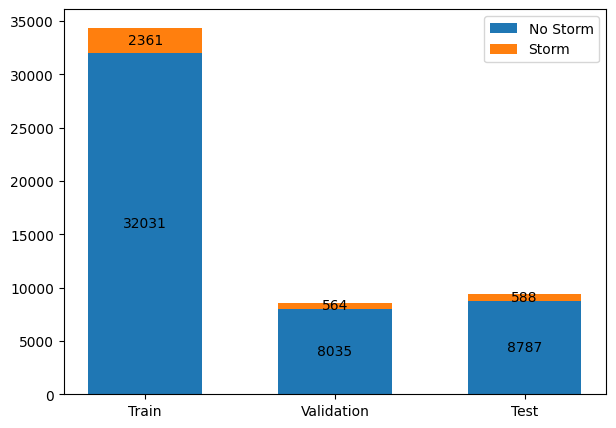

In [213]:
type = ('Train', 'Validation', 'Test')

storm_counts = {
    'No Storm': np.array([y_train.value_counts()[0], y_val.value_counts()[0], y_test.value_counts()[0]]),
    'Storm': np.array([y_train.value_counts()[1], y_val.value_counts()[1] , y_test.value_counts()[1]]),
}
width = 0.6  # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(7,5))
bottom = np.zeros(3)

for mode, count in storm_counts.items():
    p = ax.bar(type, count, width, label=mode, bottom=bottom)
    bottom += count

    ax.bar_label(p, label_type='center')

ax.legend()

plt.show()

#### Normalising the features

In [214]:
x_test

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size1,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5
0,44.944410,2.44949,2.000000,0.000000,6.708204,13.25,8.08,13.66,8.35,16.25,...,9.386392,9.386392,-18.420681,-18.420681,-18.420681,5.058028,5.143708,6.214608,6.214608,6.214608
1,44.944410,2.44949,2.000000,1.000000,0.000000,13.25,7.95,13.07,7.23,13.66,...,9.461099,9.461099,6.586172,-18.420681,-18.420681,5.058028,5.142307,5.181896,6.214608,6.214608
2,44.944410,2.44949,2.000000,1.414214,6.708204,13.16,7.68,13.84,7.32,16.25,...,9.726154,8.348775,-18.420681,-18.420681,-18.420681,5.017015,5.159228,6.214608,6.214608,6.214608
3,44.944410,2.44949,2.000000,1.732051,0.000000,13.16,7.63,13.75,7.18,16.25,...,9.894699,7.673223,-18.420681,-18.420681,-18.420681,5.040647,5.159458,6.214608,6.214608,6.214608
4,44.944410,2.44949,2.000000,1.732051,3.872983,13.75,7.05,13.03,6.24,16.25,...,10.115570,7.279319,-18.420681,-18.420681,-18.420681,5.045745,5.225800,6.214608,6.214608,6.214608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9390,44.966654,3.00000,5.477226,1.414214,3.872983,15.50,6.15,14.91,6.51,16.25,...,6.745236,7.261927,-18.420681,-18.420681,-18.420681,4.699025,4.799585,6.214608,6.214608,6.214608
9391,44.966654,3.00000,5.477226,2.000000,6.708204,13.75,6.06,15.54,6.06,16.25,...,6.354370,6.354370,-18.420681,-18.420681,-18.420681,4.704472,5.106430,6.214608,6.214608,6.214608
9392,44.966654,3.00000,5.477226,3.605551,3.872983,17.61,8.40,14.38,7.14,16.25,...,8.428362,8.342840,-18.420681,-18.420681,-18.420681,3.186766,4.891702,6.214608,6.214608,6.214608
9393,44.966654,3.00000,5.477226,3.605551,5.477226,17.65,8.44,14.38,7.05,16.25,...,8.948976,8.354674,-18.420681,-18.420681,-18.420681,3.181382,4.895972,6.214608,6.214608,6.214608


In [215]:
# normalise data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [216]:
dump(scaler, f'scaler-AirMountain-t{lead_time}.bin', compress=True)

['scaler-AirMountain-t1.bin']

In [217]:
initial_bias = np.log(pos/neg)
output_bias = tf.keras.initializers.Constant(value=initial_bias)

model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(30,)),
  tf.keras.layers.Dense(16, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Dropout(0.2),    
  tf.keras.layers.Dense(8, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid', bias_initializer=output_bias)
])

l1_reg = tf.keras.regularizers.L1(0.1)
for layer in model.layers[:]:
  layer.kernel_regularizer = l1_reg

cl_thresholds = 0.3

METRICS = [
      tf.keras.metrics.MeanSquaredError(name='bs'),
      tf.keras.metrics.TruePositives(name='tp'),
      tf.keras.metrics.TrueNegatives(name='tn'),                        
      tf.keras.metrics.Recall(name='recall', thresholds = cl_thresholds),
      tf.keras.metrics.Precision(name='precision', thresholds = cl_thresholds),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR'), 
      tf.keras.metrics.F1Score(name = 'f1_score',  threshold = cl_thresholds),
]


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=METRICS)

In [218]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [219]:
EPOCHS = 500
BATCH_SIZE = 1024

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_prc", 
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)


# train the model
model_history = model.fit(x_train, 
                          y_train, 
                          epochs=EPOCHS, 
                          callbacks = [early_stopping],
                          batch_size = BATCH_SIZE,         
                          validation_data=(x_val, y_val),
                        )

Epoch 1/500


34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - auc: 0.5645 - bs: 0.0664 - f1_score: 0.0232 - loss: 0.2624 - prc: 0.0809 - precision: 0.0527 - recall: 0.0150 - tn: 17111.4277 - tp: 0.2571 - val_auc: 0.8049 - val_bs: 0.0555 - val_f1_score: 0.0605 - val_loss: 0.2064 - val_prc: 0.2530 - val_precision: 0.5806 - val_recall: 0.0319 - val_tn: 8035.0000 - val_tp: 0.0000e+00
Epoch 2/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - auc: 0.7780 - bs: 0.0574 - f1_score: 0.1701 - loss: 0.2143 - prc: 0.2420 - precision: 0.4178 - recall: 0.1083 - tn: 17108.9707 - tp: 19.9714 - val_auc: 0.8890 - val_bs: 0.0485 - val_f1_score: 0.3423 - val_loss: 0.1758 - val_prc: 0.4277 - val_precision: 0.5512 - val_recall: 0.2482 - val_tn: 8029.0000 - val_tp: 21.0000
Epoch 3/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.8449 - bs: 0.0508 - f1_score: 0.3702 - loss: 0.1876 - prc: 0.3682 - precision: 0.4685 - recall: 0.3061 - tn: 17056.5723 - tp: 142.3428 - val_auc: 0.9128 - val_bs: 0.0437 - val_f1_score: 0.4936 - val_loss: 

In [220]:
def class_prediction(x, y):
    y_hat = model.predict(x)      
    bs = brier_score_loss(y, y_hat)    
    auc = roc_auc_score(y, y_hat)
    return y_hat, auc, bs

In [221]:
def plot_cm(y, y_hat, classification_threshold):
    # compute the contingency table    
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

In [222]:
def plot_metrics(history):
  metrics = ['loss', 'bs', 'recall', 'precision']
  for n, metric in enumerate(metrics):
    name = metric.replace("_"," ").capitalize()
    plt.subplot(2,2,n+1)
    plt.plot(history.epoch, history.history[metric], color="red", label='Train')
    plt.plot(history.epoch, history.history['val_'+metric],
             color=colors[0], linestyle="--", label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    if metric == 'loss':
      plt.ylim([0, plt.ylim()[1]])
    elif metric == 'auc':
      plt.ylim([0.5,1])
    else:
      plt.ylim([0,1])

    plt.legend()

### Performance on training data

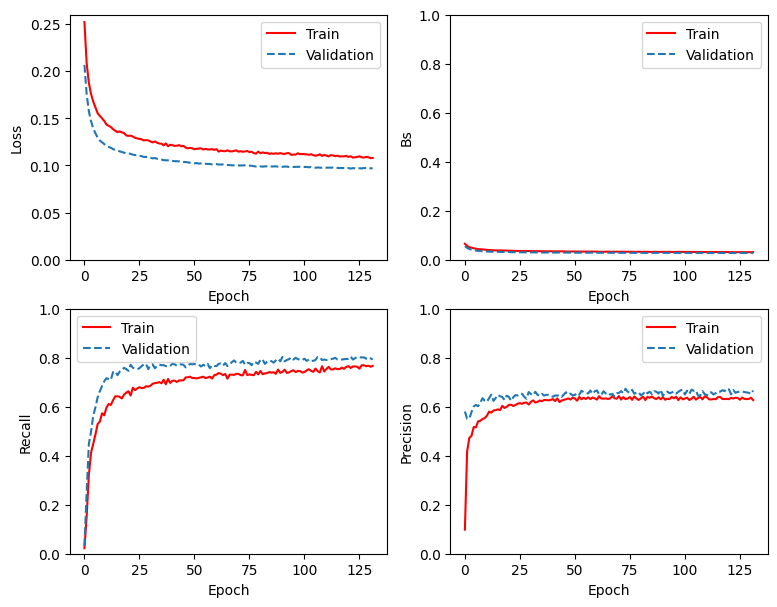

In [223]:
plot_metrics(model_history)

### Performance on testing data

In [224]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
0.10633544


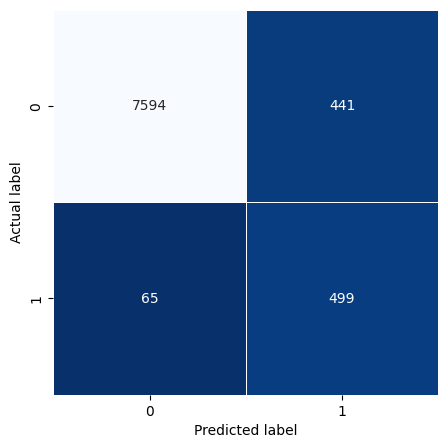

In [225]:
y_hat_val, auc_val, bs_val = class_prediction(x_val, y_val)
classification_threshold_val = cutoff_youdens_j(*roc_curve(y_val, y_hat_val))
print(classification_threshold_val)
plot_cm(y_val, y_hat_val, classification_threshold=classification_threshold_val)

In [226]:
average_precision_score(y_val, y_hat_val)

0.745014319906513

293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


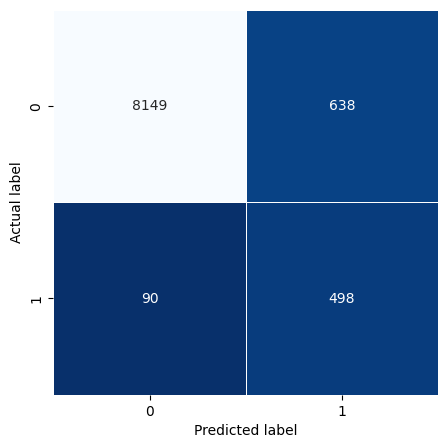

In [227]:
y_hat_test, auc_test, bs_test = class_prediction(x_test, y_test)
classification_threshold = cutoff_youdens_j(*roc_curve(y_test, y_hat_test))
plot_cm(y_test, y_hat_test, classification_threshold=classification_threshold_val)

In [228]:
average_precision_score(y_test, y_hat_test)

0.6933380309033557

In [229]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

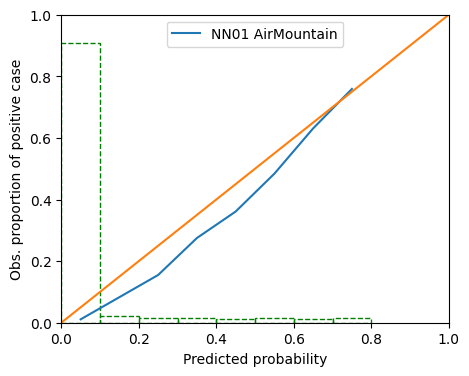

In [230]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, y_hat_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"NN0{lead_time} AirMountain")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

In [231]:
model.save(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/Airmountain-t{lead_time}.keras')

In [232]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [233]:
y_hat_train, auc_train, bs_train = class_prediction(x_train, y_train)

 155/1075 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

1075/1075 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [234]:
auc_train

0.9687160195073095

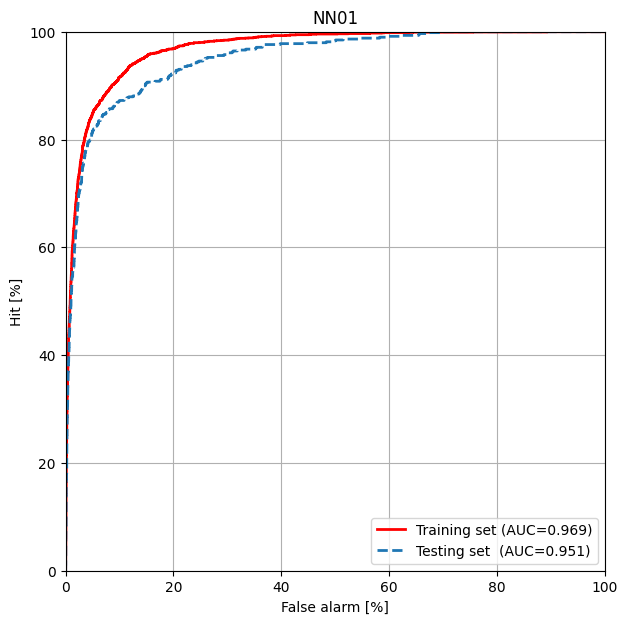

In [235]:
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train, y_hat_train, color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test, y_hat_test, color=colors[0], linestyle='--')
plt.title(f"NN0{lead_time}")
plt.legend(loc='lower right');

In [236]:
def plot_prc(name, labels, predictions, **kwargs):
    precision, recall, _ = metrics.precision_recall_curve(labels, predictions)
    plt.plot(precision, recall, label=name, linewidth=2, **kwargs)
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.grid(True)
    ax = plt.gca()
    ax.set_aspect('equal')

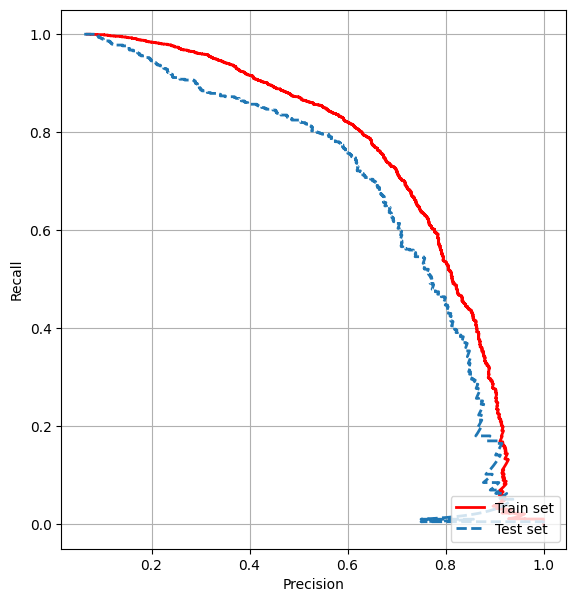

In [237]:
plot_prc("Train set", y_train, y_hat_train, color="red")
plot_prc("Test set", y_test, y_hat_test, color=colors[0], linestyle='--')
plt.legend(loc='lower right');